In [42]:
import tensorflow as tf 
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

In [43]:
texts = [
    #Positive : 2
    "The tire degradation strategy was executed perfectly.",
    "The new aerodynamic upgrades are working flawlessly.",
    "Incredible podium finish for the team today.",
    "Brilliant defensive driving to hold position.",
    "Amazing overtake on the final lap!",
    
    # Negative : 0
    "Unsafe release in the pit lane ruined everything.",
    "The engine failed right in the middle of the straight.",
    "Terrible strategy call cost them the race.",
    "The car lacks pure straight-line speed.",
    "The tire wear is absolutely awful.",
    
    # Neutral : 1
    "The team is running the hard compound tires.",
    "The ambient track temperature is 24 degrees Celsius.",
    "Car number 4 is currently in the pit lane.",
    "They are scheduled for a two-stop strategy.",
    "The race is 50 laps long."
]

labels = np.array([2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [44]:
tokens = []
for i in texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    tokens.append(words)

print(tokens)

[['the', 'tire', 'degradation', 'strategy', 'was', 'executed', 'perfectly'], ['the', 'new', 'aerodynamic', 'upgrades', 'are', 'working', 'flawlessly'], ['incredible', 'podium', 'finish', 'for', 'the', 'team', 'today'], ['brilliant', 'defensive', 'driving', 'to', 'hold', 'position'], ['amazing', 'overtake', 'on', 'the', 'final', 'lap'], ['unsafe', 'release', 'in', 'the', 'pit', 'lane', 'ruined', 'everything'], ['the', 'engine', 'failed', 'right', 'in', 'the', 'middle', 'of', 'the', 'straight'], ['terrible', 'strategy', 'call', 'cost', 'them', 'the', 'race'], ['the', 'car', 'lacks', 'pure', 'straightline', 'speed'], ['the', 'tire', 'wear', 'is', 'absolutely', 'awful'], ['the', 'team', 'is', 'running', 'the', 'hard', 'compound', 'tires'], ['the', 'ambient', 'track', 'temperature', 'is', 'degrees', 'celsius'], ['car', 'number', 'is', 'currently', 'in', 'the', 'pit', 'lane'], ['they', 'are', 'scheduled', 'for', 'a', 'twostop', 'strategy'], ['the', 'race', 'is', 'laps', 'long']]


In [45]:
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)


In [46]:
sentence_vectors = []

for sentence in tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)
    sentence_vectors.append(sentence_vector)

X_word = np.array(sentence_vectors)

print(X_word.shape)

(15, 50)


In [47]:
model2 = Sequential()

model2.add(Dense(8, activation='relu', input_shape=(X_word.shape[1],)))

model2.add(Dense(3, activation='softmax'))

In [48]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435 (1.70 KB)

 Trainable params: 435 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model2.fit(X_word,labels,epochs=100,verbose=0)
loss, accuracy = model2.evaluate(X_word, labels)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8000 - loss: 1.0882
Accuracy: 0.800000011920929


In [50]:
new_texts = [
    "A catastrophic gearbox failure forced them to retire early.",
    "The engineers are reviewing the telemetry data in the garage.",
    "The aerodynamic upgrades are performing brilliantly on the track!"
]

new_tokens = []
for i in new_texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    new_tokens.append(words)

print(new_tokens)

[['a', 'catastrophic', 'gearbox', 'failure', 'forced', 'them', 'to', 'retire', 'early'], ['the', 'engineers', 'are', 'reviewing', 'the', 'telemetry', 'data', 'in', 'the', 'garage'], ['the', 'aerodynamic', 'upgrades', 'are', 'performing', 'brilliantly', 'on', 'the', 'track']]


In [51]:
word_model.build_vocab(new_tokens, update=True)

word_model.train(
    new_tokens,
    total_examples=len(new_tokens),
    epochs=15
)

new_sentence_vectors = []

for sentence in new_tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    new_sentence_vector = np.mean(word_vectors, axis=0)
    new_sentence_vectors.append(new_sentence_vector)

new_word = np.array(new_sentence_vectors)

print(new_word.shape)

(3, 50)


In [52]:
predictions = model2.predict(new_word)
print("Predicted probabilities (Negative, Neutral, Positive):")
print(predictions[0])

# Find the index with the highest probability
predicted_class = np.argmax(predictions[0])

if predicted_class == 0:
    print("Sentiment: Negative")
elif predicted_class == 1:
    print("Sentiment: Neutral")
else:
    print("Sentiment: Positive")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted probabilities (Negative, Neutral, Positive):
[0.33458352 0.33171752 0.33369893]
Sentiment: Negative


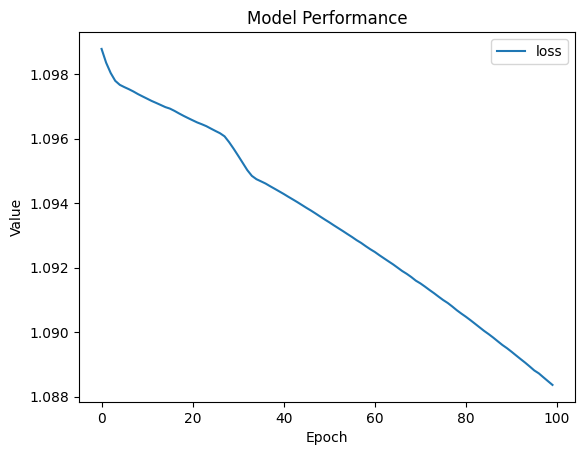

In [53]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()